# Flood vs Non-Flood Image Classification
## Multi-Architecture Deep Learning — Multi-GPU & Hyperparameter Tuning

**Dataset:** Flood Classification Dataset (Combined)
**Problem:** Binary image classification (Flood vs. Non-Flood)

### Notebook Goals
1. **Multi-GPU Utilization:** Use `nn.DataParallel` to train across Kaggle's dual T4 GPUs.
2. **Data Balancing:** Safely subsample the highly imbalanced dataset to a tunable `TOTAL_IMAGES` (Default: 3000).
3. **Hyperparameter Tuning:** Test 3 distinct configurations per architecture.
4. **Cross-Architecture Comparison:** Train and evaluate Custom CNN, ResNet-50, Inception V3, and ViT-B/16.
5. **Inference Interface:** Save best models and wrap them in a reusable deployment interface.

In [1]:
import os, copy, random, shutil, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

warnings.filterwarnings("ignore")

# --- MULTI-GPU SETUP ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_gpus = torch.cuda.device_count()
print(f"Using device: {device}")
print(f"Number of GPUs available: {num_gpus}")

Using device: cuda
Number of GPUs available: 2


In [2]:
# --- TUNABLE PARAMETERS ---
TOTAL_IMAGES = 3000 
PER_CLASS = TOTAL_IMAGES // 2

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

# --- PATHS ---
FLOOD_DIR = "/kaggle/input/datasets/dhawalsrivastava2583/flood-classification-dataset/Dataset/Flood Images"
NON_FLOOD_DIR = "/kaggle/input/datasets/dhawalsrivastava2583/flood-classification-dataset/Dataset/Non Flood Images"
DATASET_ROOT = "./balanced_dataset"
SAVE_DIR = "./saved_models"
os.makedirs(SAVE_DIR, exist_ok=True)

CLASS_NAMES = ["Flood", "Not_Flood"]
NUM_CLASSES = len(CLASS_NAMES)
SEED = 42

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

print(f"Configured for {TOTAL_IMAGES} total images ({PER_CLASS} per class).")

Configured for 3000 total images (1500 per class).


In [3]:
def build_balanced_dataset(flood_dir, non_flood_dir, out_dir, per_class):
    splits = {"train": TRAIN_RATIO, "val": VAL_RATIO, "test": TEST_RATIO}
    class_dirs = {"Flood": flood_dir, "Not_Flood": non_flood_dir}
    
    if os.path.exists(out_dir):
        print("Dataset already built. Skipping...")
        return
        
    for split in splits:
        for cls in class_dirs:
            os.makedirs(os.path.join(out_dir, split, cls), exist_ok=True)
            
    for cls, src_dir in class_dirs.items():
        files = [os.path.join(src_dir, f) for f in os.listdir(src_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        random.shuffle(files)
        files = files[:per_class]
        
        n_train = int(per_class * TRAIN_RATIO)
        n_val = int(per_class * VAL_RATIO)
        
        subsets = {
            "train": files[:n_train],
            "val": files[n_train:n_train + n_val],
            "test": files[n_train + n_val:]
        }
        
        for split, subset in subsets.items():
            for f in subset:
                dst = os.path.join(out_dir, split, cls, os.path.basename(f))
                try: os.symlink(f, dst)
                except: shutil.copy2(f, dst)
                
    print(f"Dataset successfully balanced and split at {out_dir}")

build_balanced_dataset(FLOOD_DIR, NON_FLOOD_DIR, DATASET_ROOT, PER_CLASS)

Dataset successfully balanced and split at ./balanced_dataset


In [4]:
def get_dataloaders(input_size=224, batch_size=32):
    effective_batch_size = batch_size * max(1, torch.cuda.device_count())
    
    train_tf = transforms.Compose([
        transforms.Resize((input_size, input_size)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    eval_tf = transforms.Compose([
        transforms.Resize((input_size, input_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    trn_ds = datasets.ImageFolder(os.path.join(DATASET_ROOT, "train"), transform=train_tf)
    val_ds = datasets.ImageFolder(os.path.join(DATASET_ROOT, "val"), transform=eval_tf)
    tst_ds = datasets.ImageFolder(os.path.join(DATASET_ROOT, "test"), transform=eval_tf)
    
    return (
        DataLoader(trn_ds, batch_size=effective_batch_size, shuffle=True, num_workers=4, pin_memory=True),
        DataLoader(val_ds, batch_size=effective_batch_size, shuffle=False, num_workers=4, pin_memory=True),
        DataLoader(tst_ds, batch_size=effective_batch_size, shuffle=False, num_workers=4, pin_memory=True)
    )

def train_eval_model(model, trn_ld, val_ld, epochs, lr, is_inception=False):
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()
    
    best_acc, best_state, best_preds, best_labels = 0.0, None, [], []
    
    for epoch in range(epochs):
        model.train()
        train_bar = tqdm(trn_ld, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False)
        for imgs, lbls in train_bar:
            imgs, lbls = imgs.to(device, non_blocking=True), lbls.to(device, non_blocking=True)
            optimizer.zero_grad()
            
            if is_inception:
                out, aux = model(imgs)
                loss = criterion(out, lbls) + 0.4 * criterion(aux, lbls)
            else:
                out = model(imgs)
                loss = criterion(out, lbls)
                
            loss.backward()
            optimizer.step()
            train_bar.set_postfix(loss=loss.item())
            
        model.eval()
        preds, labels = [], []
        val_bar = tqdm(val_ld, desc=f"Epoch {epoch+1}/{epochs} [Val]", leave=False)
        with torch.no_grad():
            for imgs, lbls in val_bar:
                imgs = imgs.to(device, non_blocking=True)
                out = model(imgs)
                preds.extend(torch.argmax(out, dim=1).cpu().numpy())
                labels.extend(lbls.numpy())
                
        acc = accuracy_score(labels, preds)
        if acc > best_acc:
            best_acc = acc
            state_dict = model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()
            best_state = copy.deepcopy(state_dict)
            best_preds, best_labels = preds, labels
            
    return best_acc, best_state, best_preds, best_labels

def plot_hp_subplots(arch_name, hp_results):
    fig, axes = plt.subplots(1, len(hp_results), figsize=(18, 5))
    fig.suptitle(f"{arch_name} - Hyperparameter Tuning (Validation Set)", fontsize=16, fontweight='bold')
    
    for ax, res in zip(axes, hp_results):
        cm = confusion_matrix(res['labels'], res['preds'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
        ax.set_title(f"{res['config']}\nVal Acc: {res['acc']:.4f}")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")
    plt.tight_layout()
    plt.show()

def plot_best_cm(arch_name, cm, acc, f1, prec, rec):
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f"{arch_name} - BEST MODEL (Test Set)\nAcc: {acc:.4f} | F1: {f1:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

In [5]:
HP_GRID = [
    {"name": "Config A (LR=1e-3, BS=32/GPU)", "lr": 1e-3, "bs": 32},
    {"name": "Config B (LR=1e-4, BS=32/GPU)", "lr": 1e-4, "bs": 32},
    {"name": "Config C (LR=5e-5, BS=16/GPU)", "lr": 5e-5, "bs": 16}
]

GLOBAL_RESULTS = []

def run_experiments(arch_name, model_fn, input_size=224, epochs=5, is_inception=False):
    print(f"\n{'='*50}\nEvaluating {arch_name}\n{'='*50}")
    hp_results = []
    
    for hp in HP_GRID:
        print(f"Training {hp['name']}...")
        trn_ld, val_ld, tst_ld = get_dataloaders(input_size, hp['bs'])
        
        model = model_fn()
        if torch.cuda.device_count() > 1:
            model = nn.DataParallel(model)
        model = model.to(device)
        
        val_acc, state, preds, labels = train_eval_model(model, trn_ld, val_ld, epochs, hp['lr'], is_inception)
        hp_results.append({"config": hp['name'], "acc": val_acc, "state": state, "preds": preds, "labels": labels, "bs": hp['bs']})
        
    plot_hp_subplots(arch_name, hp_results)
    
    best_run = max(hp_results, key=lambda x: x['acc'])
    print(f"\n🏆 Best Config for {arch_name}: {best_run['config']} (Val Acc: {best_run['acc']:.4f})")
    
    print("Evaluating Best Model on TEST Set...")
    best_model = model_fn()
    best_model.load_state_dict(best_run['state'])
    
    if torch.cuda.device_count() > 1:
        best_model = nn.DataParallel(best_model)
    best_model = best_model.to(device)
    best_model.eval()
    
    _, _, tst_ld = get_dataloaders(input_size, best_run['bs'])
    tst_preds, tst_labels = [], []
    
    with torch.no_grad():
        for imgs, lbls in tst_ld:
            out = best_model(imgs.to(device, non_blocking=True))
            tst_preds.extend(torch.argmax(out, dim=1).cpu().numpy())
            tst_labels.extend(lbls.numpy())
            
    cm = confusion_matrix(tst_labels, tst_preds)
    acc = accuracy_score(tst_labels, tst_preds)
    prec, rec, f1, _ = precision_recall_fscore_support(tst_labels, tst_preds, average='macro')
    
    plot_best_cm(arch_name, cm, acc, f1, prec, rec)
    
    save_path = os.path.join(SAVE_DIR, f"{arch_name.replace(' ', '_')}_best.pt")
    torch.save(best_run['state'], save_path)
    print(f"Model saved to: {save_path}\n")
    
    GLOBAL_RESULTS.append({
        "Architecture": arch_name,
        "Best Config": best_run['config'],
        "Test Accuracy": acc,
        "Test Precision": prec,
        "Test Recall": rec,
        "Test F1-Score": f1,
        "Path": save_path
    })


Evaluating Custom CNN
Training Config A (LR=1e-3, BS=32/GPU)...


Epoch 1/5 [Train]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 1/5 [Val]:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 2/5 [Train]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 2/5 [Val]:   0%|          | 0/8 [00:00<?, ?it/s]

...

Epoch 3/5 [Val]:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 4/5 [Train]:   0%|          | 0/66 [00:00<?, ?it/s]

Epoch 4/5 [Val]:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 5/5 [Train]:   0%|          | 0/66 [00:00<?, ?it/s]

Epoch 5/5 [Val]:   0%|          | 0/15 [00:00<?, ?it/s]

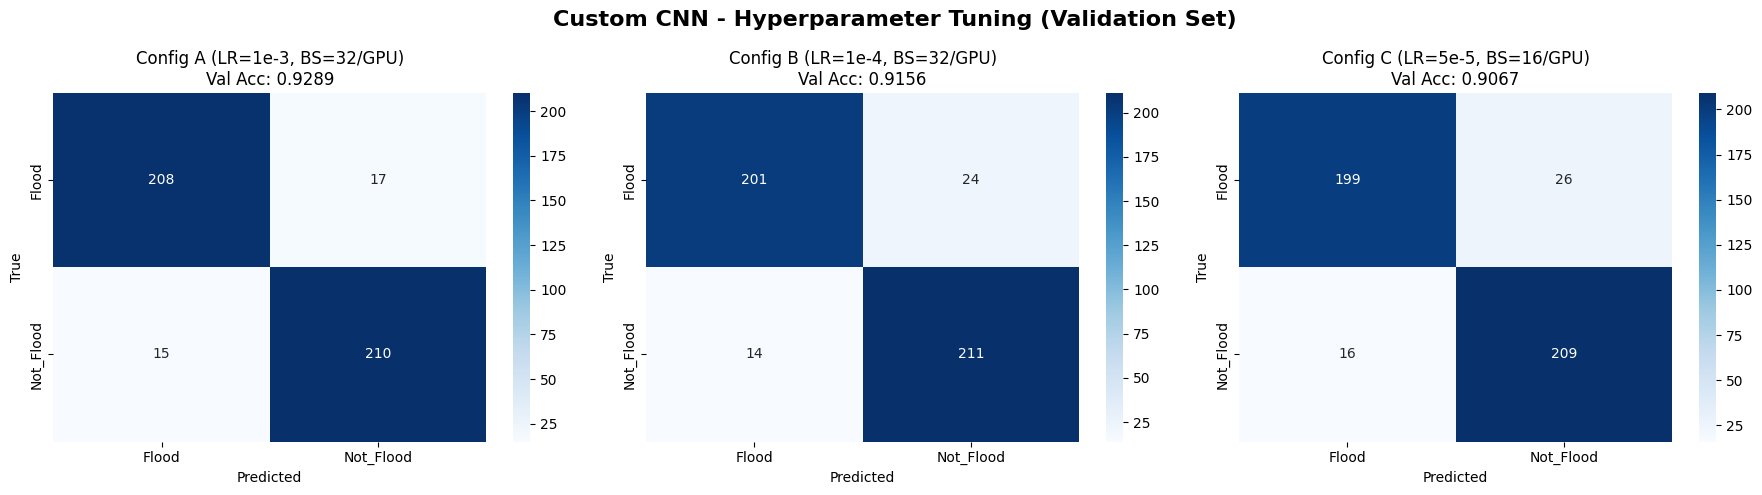


🏆 Best Config for Custom CNN: Config A (LR=1e-3, BS=32/GPU) (Val Acc: 0.9289)
Evaluating Best Model on TEST Set...


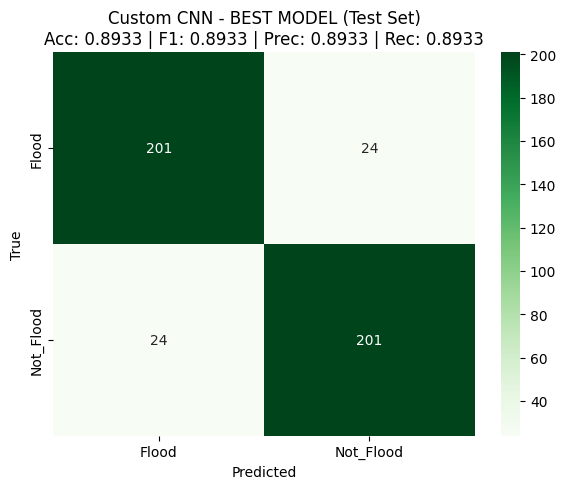

Model saved to: ./saved_models/Custom_CNN_best.pt


Evaluating ResNet 50
Training Config A (LR=1e-3, BS=32/GPU)...
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 215MB/s]


Epoch 1/5 [Train]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 1/5 [Val]:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 2/5 [Train]:   0%|          | 0/33 [00:00<?, ?it/s]

...

Epoch 3/5 [Val]:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 4/5 [Train]:   0%|          | 0/66 [00:00<?, ?it/s]

Epoch 4/5 [Val]:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 5/5 [Train]:   0%|          | 0/66 [00:00<?, ?it/s]

Epoch 5/5 [Val]:   0%|          | 0/15 [00:00<?, ?it/s]

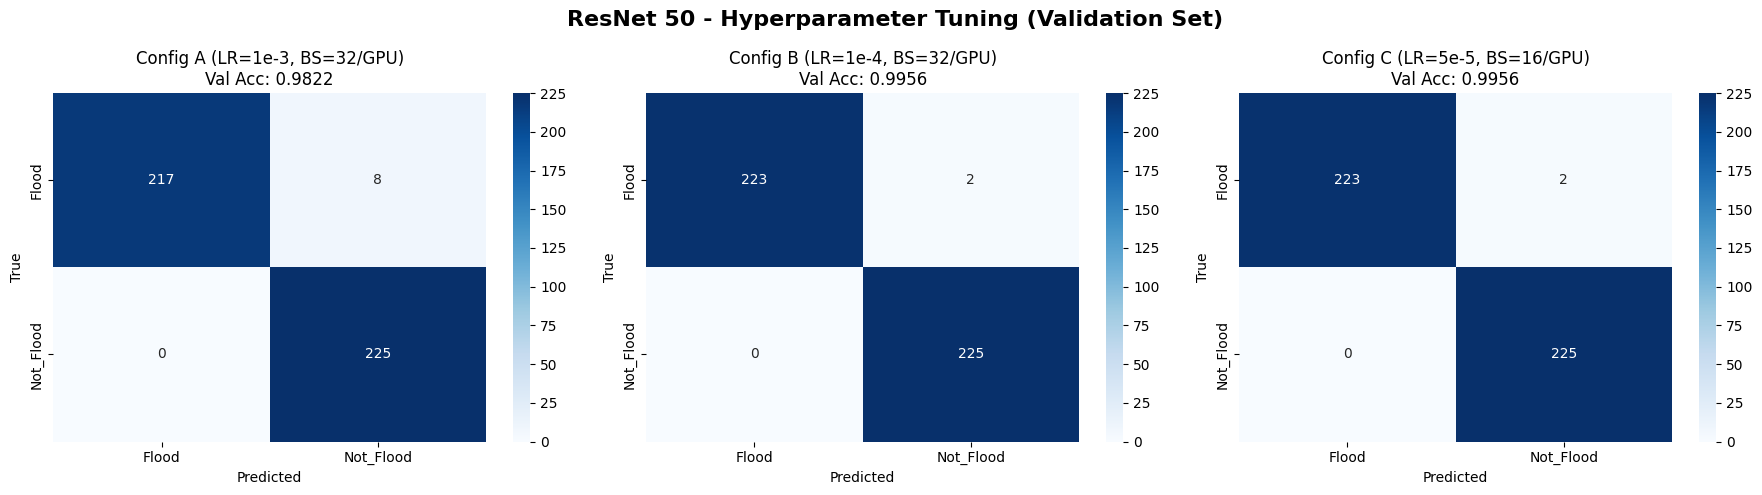


🏆 Best Config for ResNet 50: Config B (LR=1e-4, BS=32/GPU) (Val Acc: 0.9956)
Evaluating Best Model on TEST Set...


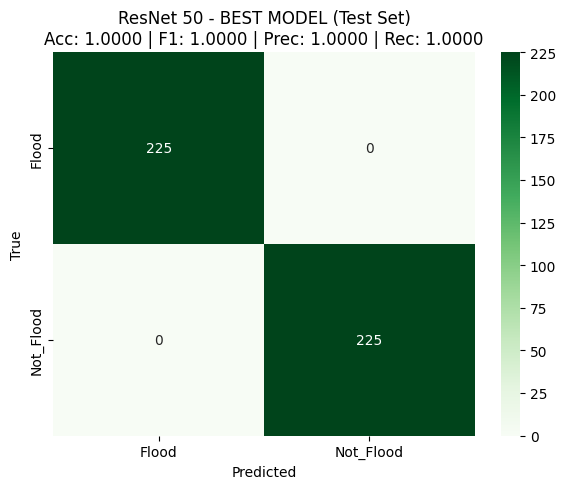

Model saved to: ./saved_models/ResNet_50_best.pt


Evaluating Inception V3
Training Config A (LR=1e-3, BS=32/GPU)...
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 208MB/s]  


Epoch 1/5 [Train]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 1/5 [Val]:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 2/5 [Train]:   0%|          | 0/33 [00:00<?, ?it/s]

...

Epoch 3/5 [Val]:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 4/5 [Train]:   0%|          | 0/66 [00:00<?, ?it/s]

Epoch 4/5 [Val]:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 5/5 [Train]:   0%|          | 0/66 [00:00<?, ?it/s]

Epoch 5/5 [Val]:   0%|          | 0/15 [00:00<?, ?it/s]

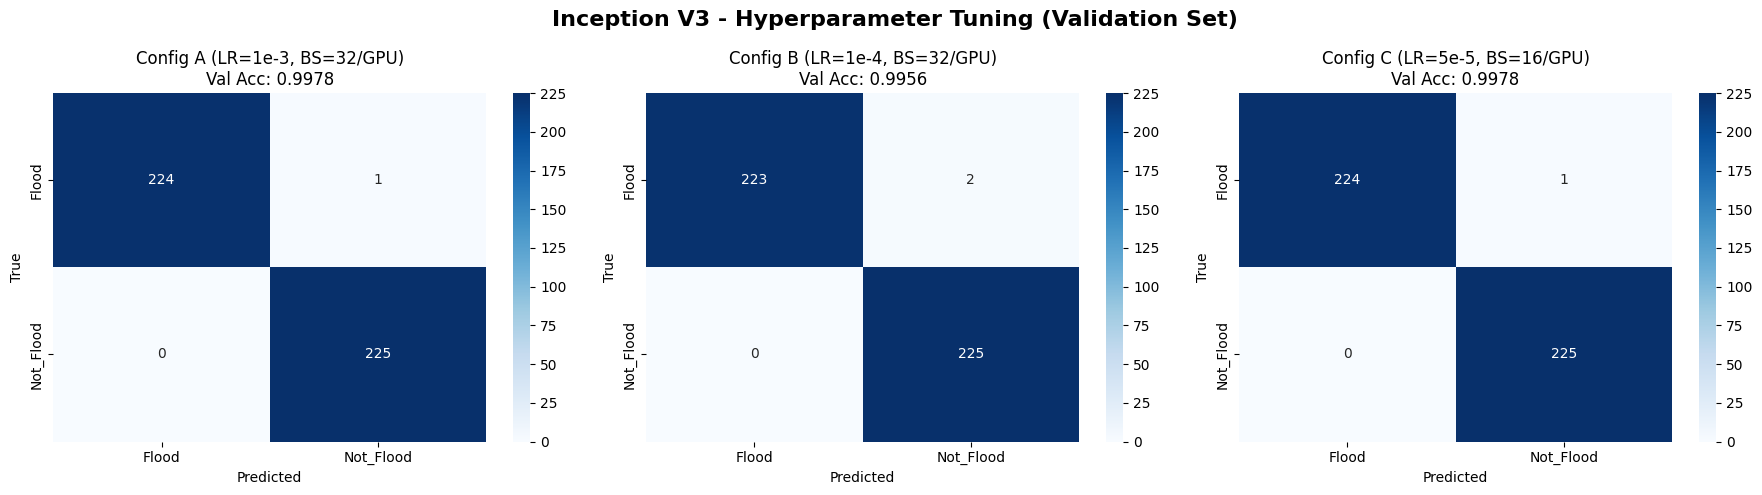


🏆 Best Config for Inception V3: Config A (LR=1e-3, BS=32/GPU) (Val Acc: 0.9978)
Evaluating Best Model on TEST Set...


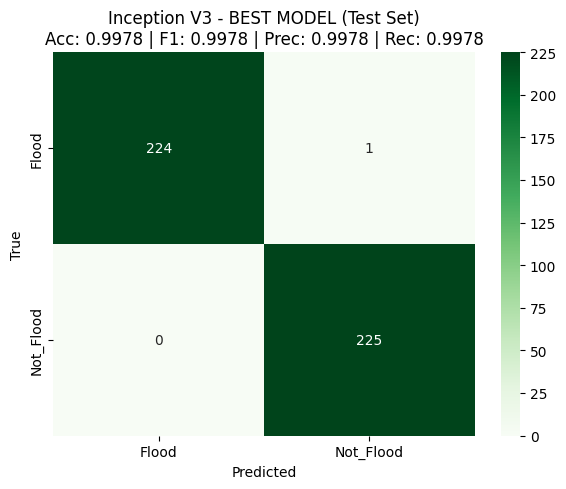

Model saved to: ./saved_models/Inception_V3_best.pt


Evaluating ViT B-16
Training Config A (LR=1e-3, BS=32/GPU)...
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 215MB/s]  


Epoch 1/5 [Train]:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 1/5 [Val]:   0%|          | 0/8 [00:00<?, ?it/s]

Epoch 2/5 [Train]:   0%|          | 0/33 [00:00<?, ?it/s]

...

Epoch 3/5 [Val]:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 4/5 [Train]:   0%|          | 0/66 [00:00<?, ?it/s]

Epoch 4/5 [Val]:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 5/5 [Train]:   0%|          | 0/66 [00:00<?, ?it/s]

Epoch 5/5 [Val]:   0%|          | 0/15 [00:00<?, ?it/s]

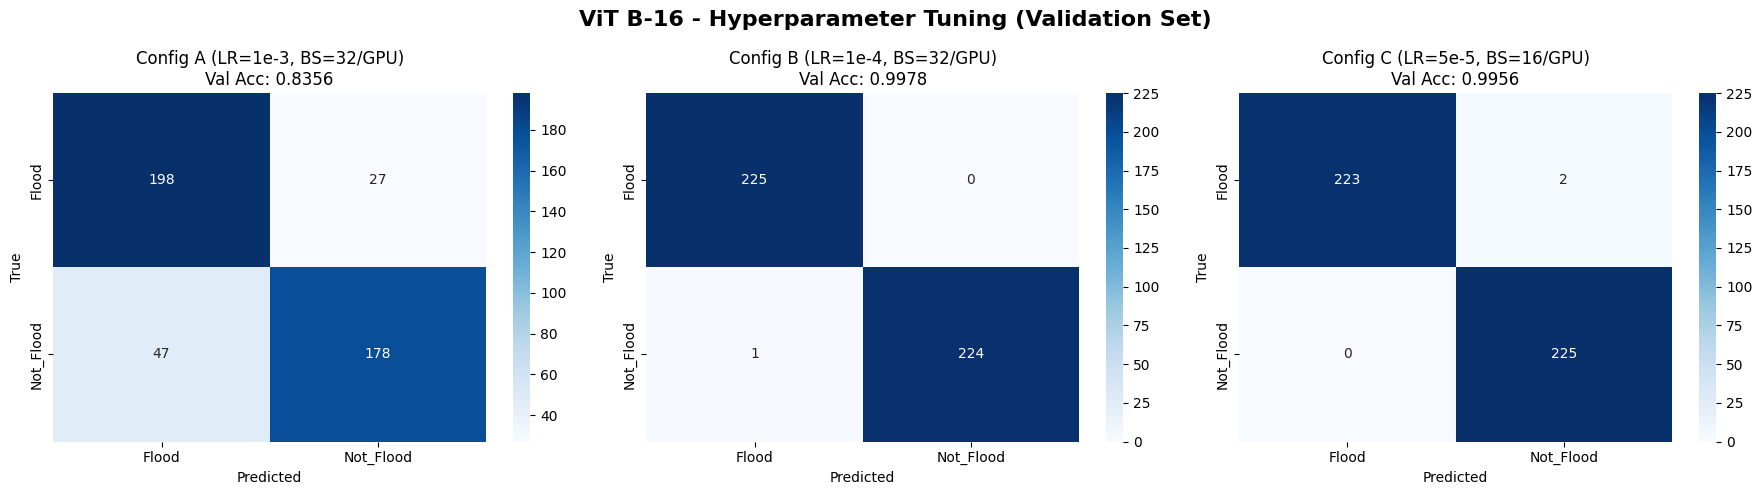


🏆 Best Config for ViT B-16: Config B (LR=1e-4, BS=32/GPU) (Val Acc: 0.9978)
Evaluating Best Model on TEST Set...


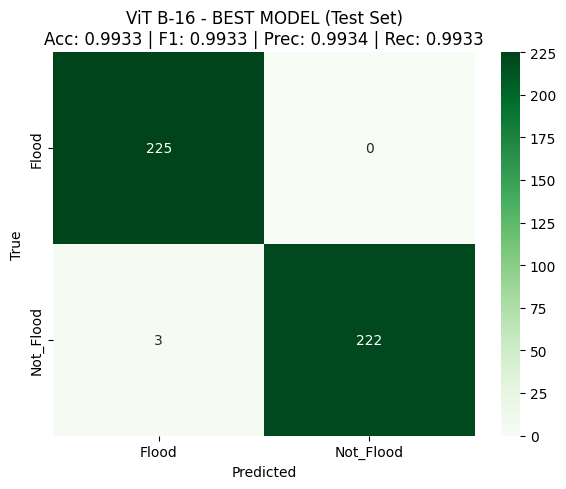

Model saved to: ./saved_models/ViT_B-16_best.pt



In [6]:
class CustomCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, NUM_CLASSES)
        )
    def forward(self, x): return self.classifier(self.features(x))

run_experiments("Custom CNN", CustomCNN, input_size=224)

def get_resnet():
    model = models.resnet50(pretrained=True)
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    return model
run_experiments("ResNet 50", get_resnet, input_size=224)

def get_inception():
    model = models.inception_v3(pretrained=True, aux_logits=True)
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    return model
run_experiments("Inception V3", get_inception, input_size=299, is_inception=True)

def get_vit():
    model = models.vit_b_16(pretrained=True)
    model.heads.head = nn.Linear(model.heads.head.in_features, NUM_CLASSES)
    return model
run_experiments("ViT B-16", get_vit, input_size=224)

=== Final Cross-Architecture Comparison ===


,Architecture,Best Config,Test Accuracy,Test Precision,Test Recall,Test F1-Score,Path
1,ResNet 50,"Config B (LR=1e-4, BS=32/GPU)",1.000000,1.000000,1.000000,1.000000,./saved_models/ResNet_50_best.pt
2,Inception V3,"Config A (LR=1e-3, BS=32/GPU)",0.997778,0.997788,0.997778,0.997778,./saved_models/Inception_V3_best.pt
3,ViT B-16,"Config B (LR=1e-4, BS=32/GPU)",0.993333,0.993421,0.993333,0.993333,./saved_models/ViT_B-16_best.pt
0,Custom CNN,"Config A (LR=1e-3, BS=32/GPU)",0.893333,0.893333,0.893333,0.893333,./saved_models/Custom_CNN_best.pt


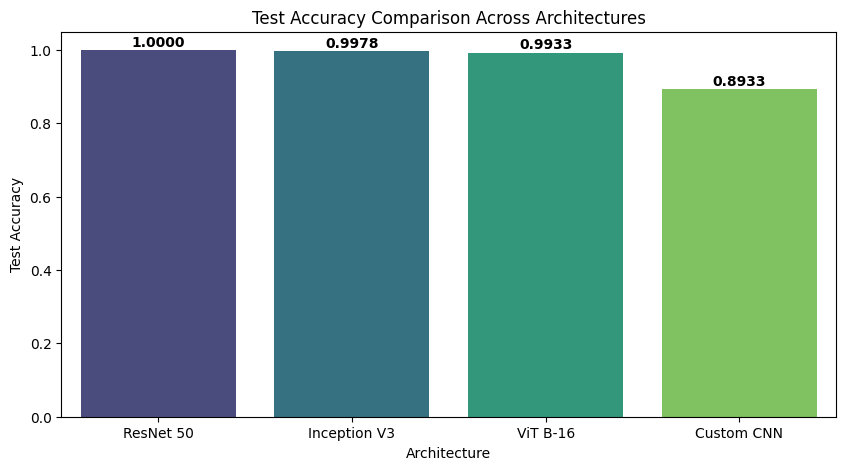

In [7]:
df_results = pd.DataFrame(GLOBAL_RESULTS).sort_values(by="Test Accuracy", ascending=False)
print("=== Final Cross-Architecture Comparison ===")
display(df_results.style.background_gradient(cmap='Blues'))

plt.figure(figsize=(10, 5))
sns.barplot(data=df_results, x='Architecture', y='Test Accuracy', palette='viridis')
plt.title("Test Accuracy Comparison Across Architectures")
plt.ylim(0, 1.05)
for i, v in enumerate(df_results['Test Accuracy']):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center', fontweight='bold')
plt.show()

In [8]:
class FloodClassifier:
    def __init__(self, arch_name, model_path):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.arch_name = arch_name
        self.input_size = 299 if "Inception" in arch_name else 224
        
        if "CNN" in arch_name: self.model = CustomCNN()
        elif "ResNet" in arch_name: self.model = get_resnet()
        elif "Inception" in arch_name: self.model = get_inception()
        elif "ViT" in arch_name: self.model = get_vit()
        else: raise ValueError("Unknown Architecture")
            
        state_dict = torch.load(model_path, map_location=self.device)
        clean_state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
        
        self.model.load_state_dict(clean_state_dict)
        self.model.to(self.device)
        self.model.eval()
        
        self.tf = transforms.Compose([
            transforms.Resize((self.input_size, self.input_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
        print(f"Loaded {arch_name} successfully from {model_path}")
        
    def predict(self, image_path):
        img = Image.open(image_path).convert('RGB')
        tensor = self.tf(img).unsqueeze(0).to(self.device)
        
        with torch.no_grad():
            out = self.model(tensor)
            pred = torch.argmax(out, dim=1).item()
            prob = torch.softmax(out, dim=1)[0][pred].item()
            
        return {"prediction": CLASS_NAMES[pred], "confidence": prob}

best_arch_row = df_results.iloc[0]
inference_engine = FloodClassifier(best_arch_row['Architecture'], best_arch_row['Path'])

sample_img = os.path.join(DATASET_ROOT, "test", "Flood", os.listdir(os.path.join(DATASET_ROOT, "test", "Flood"))[0])
result = inference_engine.predict(sample_img)
print(f"\nInference Result for sample: {result['prediction']} (Confidence: {result['confidence']:.2%})")

Loaded ResNet 50 successfully from ./saved_models/ResNet_50_best.pt

Inference Result for sample: Flood (Confidence: 100.00%)


,Architecture,Latency (ms)
0,Custom CNN,0.552878
1,ResNet 50,5.423505
2,Inception V3,11.266088
3,ViT B-16,14.008303


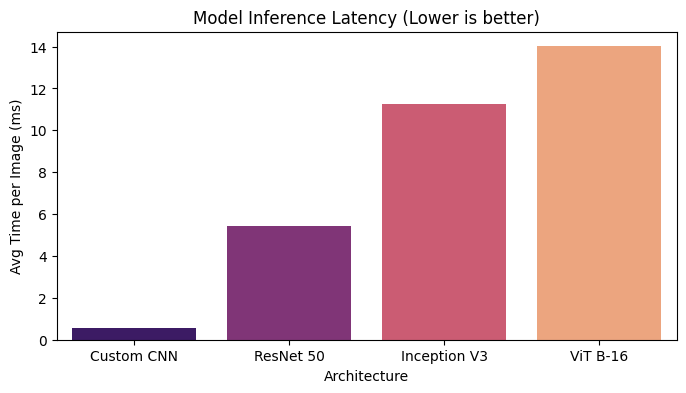

In [12]:
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Inference timing function
def benchmark_inference(arch_name, model_fn, img_size=224, iterations=100):
    model = model_fn().to(device).eval()
    dummy_input = torch.randn(1, 3, img_size, img_size).to(device)
    
    # Warm-up
    for _ in range(10): model(dummy_input)
    
    # Timing
    start = time.time()
    with torch.no_grad():
        for _ in range(iterations): model(dummy_input)
    end = time.time()
    
    return (end - start) / iterations * 1000  # ms per inference

# Run benchmarks
bench_data = []
archs = [
    ("Custom CNN", CustomCNN, 224),
    ("ResNet 50", get_resnet, 224),
    ("Inception V3", get_inception, 299),
    ("ViT B-16", get_vit, 224)
]

for name, fn, size in archs:
    ms = benchmark_inference(name, fn, size)
    bench_data.append({"Architecture": name, "Latency (ms)": ms})

# Results
df_bench = pd.DataFrame(bench_data)
display(df_bench)

# Visualization
plt.figure(figsize=(8, 4))
sns.barplot(data=df_bench, x="Architecture", y="Latency (ms)", palette="magma")
plt.title("Model Inference Latency (Lower is better)")
plt.ylabel("Avg Time per Image (ms)")
plt.show()

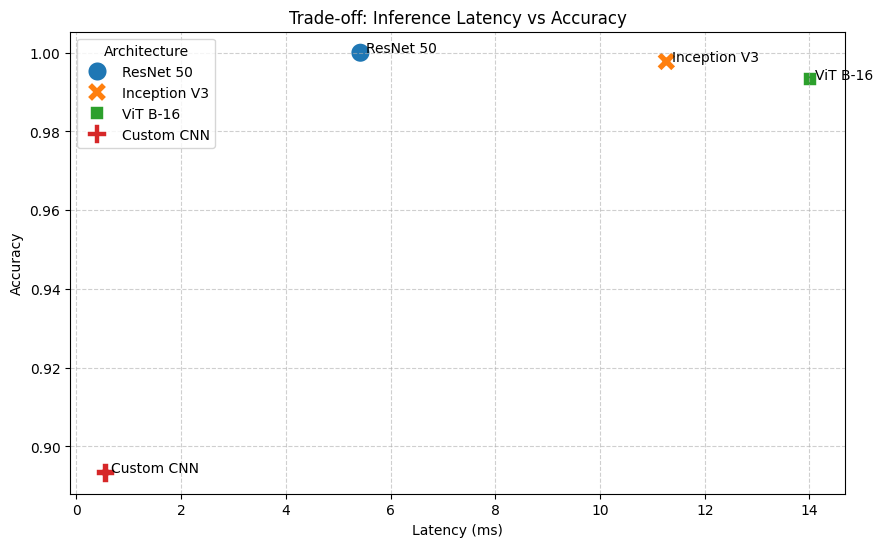

In [22]:
# Merge results
df_merged = df_results.rename(columns={"Architecture": "Architecture", "Test Accuracy": "Accuracy"}).merge(df_bench, on="Architecture")

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_merged, x="Latency (ms)", y="Accuracy", hue="Architecture", s=200, style="Architecture")

for i in range(df_merged.shape[0]):
    plt.text(df_merged["Latency (ms)"][i]+0.1, df_merged["Accuracy"][i], df_merged["Architecture"][i])

plt.title("Trade-off: Inference Latency vs Accuracy")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [11]:
!zip -r saved_models_deep_learning.zip /kaggle/working/saved_models

  adding: kaggle/working/saved_models/ (stored 0%)
  adding: kaggle/working/saved_models/Inception_V3_best.pt (deflated 7%)
  adding: kaggle/working/saved_models/ViT_B-16_best.pt (deflated 7%)
  adding: kaggle/working/saved_models/Custom_CNN_best.pt (deflated 8%)
  adding: kaggle/working/saved_models/ResNet_50_best.pt (deflated 7%)


# Testing Best model with GradCam for Explainable AI

In [ ]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image

# 1. Define Architecture exactly as trained
def get_resnet():
    model = models.resnet50(pretrained=False) # Architecture only
    model.fc = nn.Linear(model.fc.in_features, 2) # Binary classes
    return model

# 2. Setup Inference
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = get_resnet()

# 3. Load Weights (Ensure the path is correct)
model_path = "/kaggle/input/models/yazanalatout/resnet-50-flood-classification/pytorch/default/1/ResNet_50_best.pt"
state_dict = torch.load(model_path, map_location=device)

# 4. Handle DataParallel prefix
clean_state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
model.load_state_dict(clean_state_dict)

model = model.to(device).eval()

# 5. Verification
print("Model loaded successfully on:", device)

Model loaded successfully on: cpu


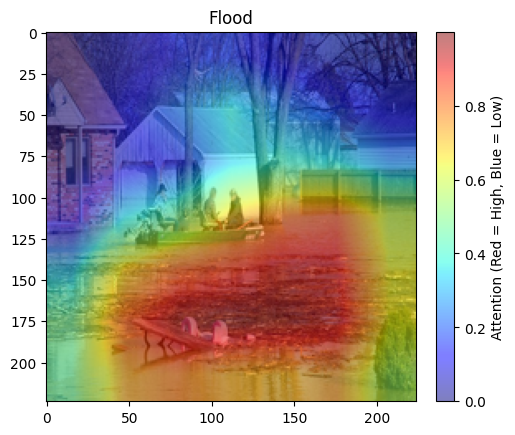

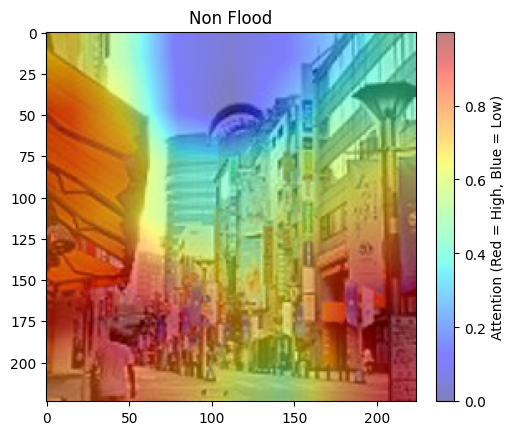

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 1. Setup lists and hooks for both activations AND gradients
feature_maps = []
gradients = []

def forward_hook(module, input, output):
    feature_maps.append(output)

def backward_hook(module, grad_input, grad_output):
    gradients.append(grad_output[0])

# Hook the final conv layer of ResNet50
model.layer4.register_forward_hook(forward_hook)
model.layer4.register_full_backward_hook(backward_hook)

def get_gradcam(img_path, title):
    # Clear previous hook data
    feature_maps.clear()
    gradients.clear()
    
    # Prepare image
    img = Image.open(img_path).convert('RGB')
    tensor = transforms.Compose([
        transforms.Resize((224, 224)), 
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])(img).unsqueeze(0).to(device)
    
    # Forward pass
    output = model(tensor)
    pred_idx = torch.argmax(output, dim=1).item()
    
    # Backward pass
    model.zero_grad()
    output[0, pred_idx].backward()
    
    # Extract activations and gradients
    activations = feature_maps[0].squeeze() 
    grads = gradients[0].squeeze() 
    
    # Global average pool the gradients
    pooled_grads = torch.mean(grads, dim=[1, 2])
    
    # Weight the activations
    for i in range(activations.shape[0]):
        activations[i, :, :] *= pooled_grads[i]
        
    # Generate heatmap
    cam = torch.mean(activations, dim=0).detach().cpu().numpy()
    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (224, 224))
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    plt.title(title)
    
    # Plot
    plt.imshow(img.resize((224, 224)))
    heatmap = plt.imshow(cam, alpha=0.5, cmap='jet')
    
    # Add Heat Bar (Colorbar)
    cbar = plt.colorbar(heatmap, fraction=0.046, pad=0.04)
    cbar.set_label('Attention (Red = High, Blue = Low)')
    
    plt.show()    

# Run Inference
get_gradcam("/kaggle/input/datasets/dhawalsrivastava2583/flood-classification-dataset/Dataset/Flood Images/Flood_1043.jpg", "Flood")
get_gradcam("/kaggle/input/datasets/dhawalsrivastava2583/flood-classification-dataset/Dataset/Non Flood Images/1000.jpg", "Non Flood")